### ESS analysis for KuaiRec dataset

This notebook computes **Effective Sample Size (ESS)** diagnostics for the KuaiRec dataset, following the definition in the paper:

\[\mathrm{ESS} = \frac{\left(\sum_{i=1}^N w_i\right)^2}{\sum_{i=1}^N w_i^2}\]

Here, \(w_i = \pi_t(a_i \mid x_i) / \pi_b(a_i \mid x_i)\) are importance weights for a chosen target policy \(\pi_t\) relative to a logging policy \(\pi_b\).

We **do not implement any counterfactual estimators** (IPS, SNIPS, CRM, DR, etc.) in this notebook. It only takes pre-computed importance weights and associated performance values as input and:

- computes absolute ESS and relative ESS (ESS / N)
- visualizes **ESS vs performance** for different models / configurations.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

def compute_ess(weights):
    """Effective Sample Size (ESS) diagnostic.

    ESS = (sum_i w_i)^2 / sum_i w_i^2
    """
    w = np.asarray(weights, dtype=float).ravel()
    if w.size == 0:
        return np.nan
    num = np.square(w.sum())
    denom = np.square(w).sum()
    return float(num / denom)


def compute_relative_ess(weights):
    """Relative ESS = ESS / N, where N is the number of samples."""
    w = np.asarray(weights, dtype=float).ravel()
    if w.size == 0:
        return np.nan
    ess = compute_ess(w)
    return float(ess / w.size)


def summarize_ess(weight_dict):
    """Given a dict mapping configuration names to 1D arrays of weights,
    return a DataFrame with N, ESS, and relative ESS.
    """
    rows = []
    for name, w in weight_dict.items():
        w = np.asarray(w, dtype=float).ravel()
        N = w.size
        ess = compute_ess(w)
        rel_ess = ess / N if N > 0 else np.nan
        rows.append(
            {
                "config": name,
                "N": N,
                "ESS": ess,
                "relative_ESS": rel_ess,
            }
        )
    return pd.DataFrame(rows)


In [6]:
def plot_ess_vs_performance(df, dataset_name, performance_col="performance"):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(df["relative_ESS"], df[performance_col])
    for _, row in df.iterrows():
        ax.annotate(
            row["config"],
            (row["relative_ESS"], row[performance_col]),
            xytext=(3, 3),
            textcoords="offset points",
            fontsize=8,
        )
    ax.set_xlabel("Relative ESS (ESS / N)")
    ax.set_ylabel(performance_col)
    ax.set_title(f"ESS vs performance — {dataset_name}")
    plt.tight_layout()
    plt.show()


In [7]:
# EXAMPLE ONLY: replace `weight_dict` and `performance` with your real results.

rng = np.random.default_rng(0)

weight_dict = {
    "config_1": rng.lognormal(mean=0.0, sigma=0.1, size=50_000),
    "config_2": rng.lognormal(mean=0.0, sigma=0.5, size=50_000),
    "config_3": rng.lognormal(mean=0.0, sigma=1.0, size=50_000),
}

df_ess = summarize_ess(weight_dict)

# Example placeholder performance metric (e.g., IPS-estimated Recall@K or NDCG@K)
df_ess["performance"] = [0.20, 0.23, 0.22]

df_ess


,config,N,ESS,relative_ESS,performance
0,config_1,50000,49501.291004,0.990026,0.20
1,config_2,50000,38942.720353,0.778854,0.23
2,config_3,50000,18223.643229,0.364473,0.22


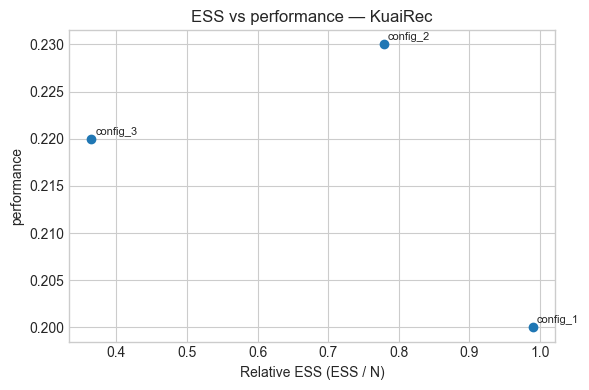

In [8]:
plot_ess_vs_performance(df_ess, dataset_name="KuaiRec", performance_col="performance")


KuaiRec — N = 12530806
ESS (1/propensity weights): 2737883.98
Relative ESS (ESS / N): 0.2185
Naive mean rating (performance placeholder): 0.9445


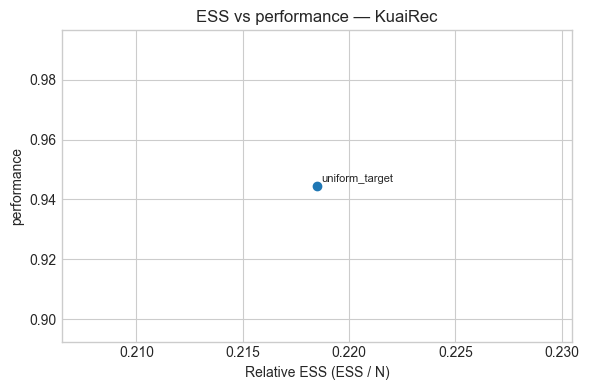

In [9]:
# Compute ESS for KuaiRec directly from the logged data.
# As with the other datasets, we:
# - estimate item propensities via popularity
# - set weights w_i ∝ 1 / propensity_i
# - compute ESS and relative ESS
# - use naive mean rating as a simple performance placeholder

import os

kuairec_path = os.path.join("..", "data", "kuairec_data", "kuairec_combined.csv")
kuairec_df = pd.read_csv(kuairec_path)

N_kuairec = len(kuairec_df)

# Estimate logging propensities via item popularity
item_counts = kuairec_df["itemId"].value_counts()
propensities = (item_counts / float(N_kuairec)).to_dict()
min_propensity = 1e-5  # slightly smaller, KuaiRec is larger
kuairec_df["propensity"] = kuairec_df["itemId"].map(lambda i: max(propensities.get(i, min_propensity), min_propensity))

# Importance weights for a uniform target over items: w_i ∝ 1 / propensity_i
weights_kuairec = 1.0 / kuairec_df["propensity"].values

ess_kuairec = compute_ess(weights_kuairec)
rel_ess_kuairec = compute_relative_ess(weights_kuairec)

# Simple "performance" = naive mean rating (logged data)
perf_kuairec = float(kuairec_df["rating"].mean())

print(f"KuaiRec — N = {N_kuairec}")
print(f"ESS (1/propensity weights): {ess_kuairec:.2f}")
print(f"Relative ESS (ESS / N): {rel_ess_kuairec:.4f}")
print(f"Naive mean rating (performance placeholder): {perf_kuairec:.4f}")

# One-row DataFrame for plotting helper
df_ess_kuairec = pd.DataFrame({
    "config": ["uniform_target"],
    "N": [N_kuairec],
    "ESS": [ess_kuairec],
    "relative_ESS": [rel_ess_kuairec],
    "performance": [perf_kuairec],
})

df_ess_kuairec

plot_ess_vs_performance(df_ess_kuairec, dataset_name="KuaiRec", performance_col="performance")
